In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 1. Load the dataset
# Make sure the filename matches exactly what you uploaded
filename = 'source_credibility_dataset_200.csv'
try:
    df = pd.read_csv(filename)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: {filename} not found. Please upload the CSV file to Colab files.")

# 2. Select Features and Target
# We use numeric columns + language. We exclude identifiers like URL and source_name.
features = ['past_fake', 'past_real', 'domain_age_years', 'followers', 'language']
target = 'credibility_label'

X = df[features].copy()
y = df[target]

# 3. Preprocessing
# We need to convert 'language' (text) into numbers using LabelEncoder
lang_encoder = LabelEncoder()
X['language'] = lang_encoder.fit_transform(X['language'])

# 4. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Training Complete.")
print(f"Accuracy on Test Set: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset loaded successfully.

Model Training Complete.
Accuracy on Test Set: 95.00%

Classification Report:
               precision    recall  f1-score   support

        High       0.94      0.94      0.94        18
         Low       1.00      1.00      1.00         8
      Medium       0.93      0.93      0.93        14

    accuracy                           0.95        40
   macro avg       0.96      0.96      0.96        40
weighted avg       0.95      0.95      0.95        40



In [3]:
# Save the model and the encoder (needed to process new data later)
model_filename = 'credibility_rf_model.pkl'
encoder_filename = 'lang_encoder.pkl'

joblib.dump(rf_model, model_filename)
joblib.dump(lang_encoder, encoder_filename)

print(f"Model saved as '{model_filename}'")
print(f"Encoder saved as '{encoder_filename}'")

# Optional: Download the files to your local computer
try:
    from google.colab import files
    files.download(model_filename)
    files.download(encoder_filename)
    print("Download started...")
except ImportError:
    print("Not running in Colab or file download not supported here.")

Model saved as 'credibility_rf_model.pkl'
Encoder saved as 'lang_encoder.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started...


In [4]:
import pandas as pd
import joblib

# 1. Load the saved model and encoder
# (This ensures we are using the stored version, not the one in memory)
loaded_model = joblib.load('credibility_rf_model.pkl')
loaded_encoder = joblib.load('lang_encoder.pkl')

print("Model and Encoder loaded successfully.")

# 2. Define a helper function to predict credibility
def check_channel_credibility(source_name, past_fake, past_real, age, followers, language):
    # Create a DataFrame for the single input to match training format
    input_data = pd.DataFrame([{
        'past_fake': past_fake,
        'past_real': past_real,
        'domain_age_years': age,
        'followers': followers,
        'language': language
    }])

    # Encode the language using the loaded encoder
    try:
        input_data['language'] = loaded_encoder.transform(input_data['language'])
    except ValueError:
        print(f"Error: Language '{language}' not recognized by encoder.")
        return None

    # Predict probabilities
    probabilities = loaded_model.predict_proba(input_data)[0]
    # Get class labels in the order of probabilities
    class_labels = loaded_model.classes_

    # Create a dictionary of class labels and their probabilities
    prediction_probabilities = {label: prob for label, prob in zip(class_labels, probabilities)}

    # Return only the 'High' credibility probability
    return prediction_probabilities.get('High', 0.0)

# 3. Test with some Sample News Channels
# You can change these values to test different scenarios
test_channels = [
    # Case A: A channel with lots of fake news (Expected: Low probability for High)
    {'name': 'Gossip King', 'past_fake': 50, 'past_real': 5, 'age': 1, 'followers': 5000, 'lang': 'Sinhala'},

    # Case B: A reputable channel (Expected: High probability for High)
    {'name': 'Daily Truth', 'past_fake': 2, 'past_real': 1500, 'age': 15, 'followers': 2000000, 'lang': 'English'},

    # Case C: A new channel with mixed history (Expected: Medium or Low probability for High)
    {'name': 'News Today', 'past_fake': 5, 'past_real': 20, 'age': 3, 'followers': 15000, 'lang': 'Tamil'}
]

print("\n--- Testing New Channels ---")
for channel in test_channels:
    credibility_score = check_channel_credibility(
        channel['name'],
        channel['past_fake'],
        channel['past_real'],
        channel['age'],
        channel['followers'],
        channel['lang']
    )
    print(f"Channel: {channel['name']:<15} | Credibility Score: {credibility_score * 100:.2f}%")

Model and Encoder loaded successfully.

--- Testing New Channels ---
Channel: Gossip King     | Credibility Score: 0.00%
Channel: Daily Truth     | Credibility Score: 86.00%
Channel: News Today      | Credibility Score: 2.00%


In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import joblib

# 1. Load the model and encoder
try:
    loaded_model = joblib.load('credibility_rf_model.pkl')
    loaded_encoder = joblib.load('lang_encoder.pkl')
except FileNotFoundError:
    print("Error: Model files not found. Please run the training cell first.")

# 2. Create Input Widgets
style = {'description_width': 'initial'}

w_name = widgets.Text(
    value='',
    placeholder='e.g., Daily News',
    description='Channel Name:',
    style=style
)

w_fake = widgets.IntText(
    value=0,
    description='Past Fake News Count:',
    style=style
)

w_real = widgets.IntText(
    value=0,
    description='Past Real News Count:',
    style=style
)

w_age = widgets.IntText(
    value=0,
    description='Domain Age (Years):',
    style=style
)

w_followers = widgets.IntText(
    value=0,
    description='Followers:',
    style=style
)

w_lang = widgets.Dropdown(
    options=['Sinhala', 'Tamil', 'English'], # Ensure these match your training data
    value='Sinhala',
    description='Language:',
    style=style
)

btn_predict = widgets.Button(
    description='Predict Credibility',
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    icon='check'
)

output = widgets.Output()

# 3. Define Button Click Event
def on_predict_clicked(b):
    with output:
        clear_output()

        # Get data from widgets
        input_data = pd.DataFrame([{
            'past_fake': w_fake.value,
            'past_real': w_real.value,
            'domain_age_years': w_age.value,
            'followers': w_followers.value,
            'language': w_lang.value
        }])

        try:
            # Encode language
            input_data['language'] = loaded_encoder.transform(input_data['language'])

            # Predict probabilities
            probabilities = loaded_model.predict_proba(input_data)[0]
            class_labels = loaded_model.classes_
            prediction_probabilities = {label: prob for label, prob in zip(class_labels, probabilities)}

            # Display Result
            print(f"--- Result for '{w_name.value}' ---")

            # Get the probability for 'High' credibility
            high_credibility_score = prediction_probabilities.get('High', 0.0)
            print(f"Credibility Score: {high_credibility_score * 100:.2f}%")

            # Optionally, still show all probabilities for detailed view if desired
            # print("Predicted Credibility Probabilities:")
            # for label, prob in prediction_probabilities.items():
            #     print(f"  {label}: {prob * 100:.2f}%")

        except Exception as e:
            print(f"Error during prediction: {e}")

btn_predict.on_click(on_predict_clicked)

# 4. Display the UI
print("Enter News Channel Details below to test:")
ui = widgets.VBox([w_name, w_fake, w_real, w_age, w_followers, w_lang, btn_predict])
display(ui, output)

Enter News Channel Details below to test:


Output()

In [7]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------- Load trained model/encoder if not in memory ----------
if "rf_model" not in globals():
    rf_model = joblib.load("credibility_rf_model.pkl")
if "lang_encoder" not in globals():
    lang_encoder = joblib.load("lang_encoder.pkl")

# ---------- Rebuild X, y, and split if not available ----------
if "X_train" not in globals() or "X_test" not in globals():
    filename = "source_credibility_dataset_200.csv"
    df = pd.read_csv(filename)

    features = ['past_fake', 'past_real', 'domain_age_years', 'followers', 'language']
    target = 'credibility_label'

    X = df[features].copy()
    y = df[target].copy()

    # IMPORTANT: use the SAME encoder mapping (already trained)
    X['language'] = lang_encoder.transform(X['language'])

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

# ---------- Evaluate ----------
y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("✅ Model Evaluation")
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test  Accuracy: {test_acc * 100:.2f}%")

print("\n✅ Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix (numbers)
labels = list(rf_model.classes_)
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

print("✅ Confusion Matrix (rows=true, cols=pred):")
cm_df = pd.DataFrame(cm, index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])
display(cm_df)


✅ Model Evaluation
Train Accuracy: 100.00%
Test  Accuracy: 95.00%

✅ Classification Report (Test):
              precision    recall  f1-score   support

        High       0.94      0.94      0.94        18
         Low       1.00      1.00      1.00         8
      Medium       0.93      0.93      0.93        14

    accuracy                           0.95        40
   macro avg       0.96      0.96      0.96        40
weighted avg       0.95      0.95      0.95        40

✅ Confusion Matrix (rows=true, cols=pred):


,Pred_High,Pred_Low,Pred_Medium
True_High,17,0,1
True_Low,0,8,0
True_Medium,1,0,13


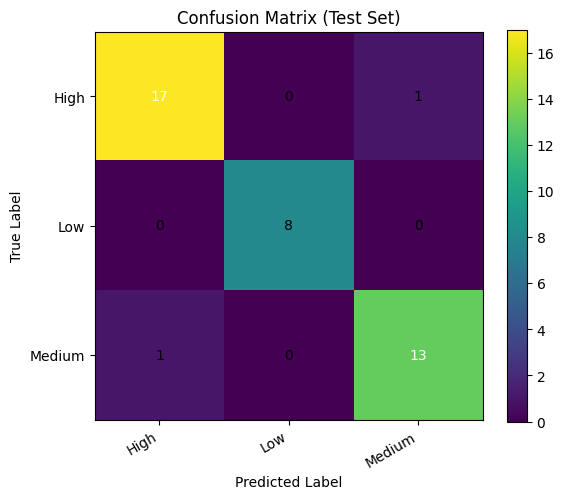

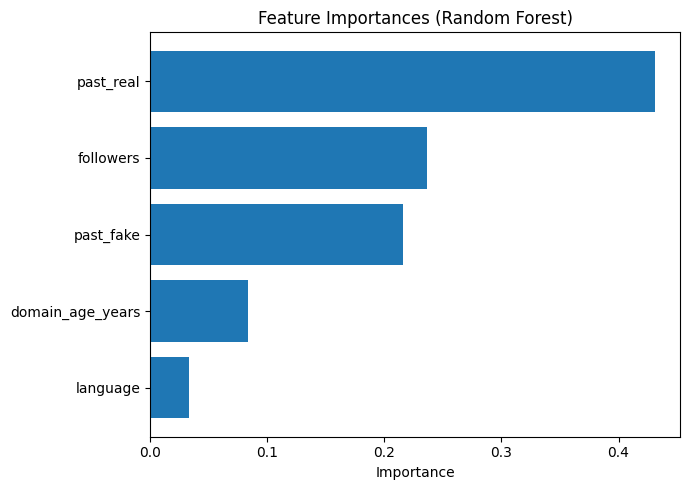

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict again (safe if already exists)
y_test_pred = rf_model.predict(X_test)
labels = list(rf_model.classes_)

# ---------- Confusion Matrix Plot ----------
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=30, ha='right')
plt.yticks(tick_marks, labels)

# Add numbers inside cells
thresh = cm.max() / 2.0 if cm.max() != 0 else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# ---------- Feature Importance Plot ----------
feature_names = list(X_train.columns)
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(7,5))
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


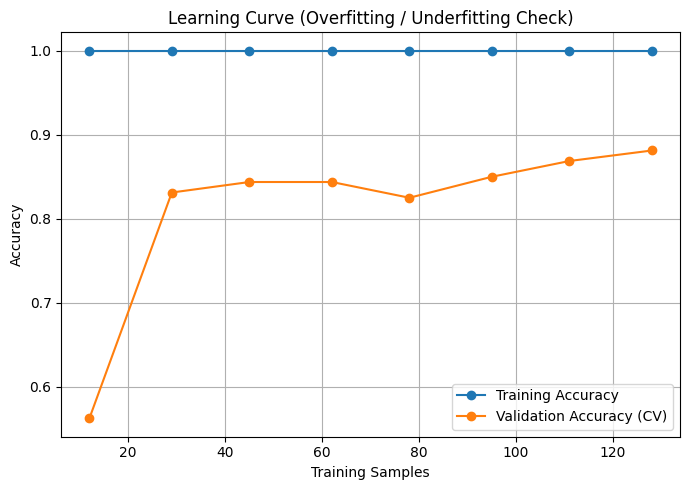

Final Training Acc (avg):   100.00%
Final Validation Acc (avg): 88.12%
Gap (Train - Val):          11.88%

🔴 Likely OVERFITTING: training much higher than validation.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy (CV)")
plt.title("Learning Curve (Overfitting / Underfitting Check)")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Simple diagnosis ----
final_train = train_mean[-1]
final_val   = val_mean[-1]
gap = final_train - final_val

print(f"Final Training Acc (avg):   {final_train*100:.2f}%")
print(f"Final Validation Acc (avg): {final_val*100:.2f}%")
print(f"Gap (Train - Val):          {gap*100:.2f}%")

if final_train < 0.75 and final_val < 0.75:
    print("\n🟡 Likely UNDERFITTING: both train & validation are low.")
elif gap > 0.08:
    print("\n🔴 Likely OVERFITTING: training much higher than validation.")
else:
    print("\n🟢 Looks OK: train and validation are reasonably close.")
